# **Models Evaluation**

## **Installations and Setup**

In [32]:
import os
import torch.fx
import torch
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from pathlib import Path
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from indic_transliteration import sanscript
import warnings

warnings.filterwarnings("ignore")

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [34]:
ROOT_DIR = Path.cwd().parent
RESULTS_DIR = ROOT_DIR / "results" / "evaluation"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAINED_MODELS_DIR = ROOT_DIR / "trained_models"
OFFLINE_DIR = ROOT_DIR / "offline_models"
ML_MODELS_DIR = TRAINED_MODELS_DIR / "ml_baselines"

print(f"Results will be saved to: {RESULTS_DIR}")

Results will be saved to: /home/aakash/rizwan/NLP_Project/results/evaluation


In [35]:
LABEL_NAMES = [
    "Situational Awareness",
    "Critical Rescue",
    "Volunteering and Donations",
    "Irrelevant",
    "Resource Requests",
]
label2id = {label: i for i, label in enumerate(LABEL_NAMES)}

In [36]:
BASE_MODEL_IDS = {
    "local_xlm_roberta": "xlm-roberta-base",
    "local_muril": "google/muril-base-cased",
    "local_indic_bert": "ai4bharat/indic-bert",
    "local_mbert": "bert-base-multilingual-cased"}

In [37]:
def download_base_model(local_name: str) -> Path:
    """
    Download a base HF model into offline_models/<local_name> if missing.
    """
    if local_name not in BASE_MODEL_IDS:
        raise ValueError(f"Unknown model key: {local_name}")

    hf_id = BASE_MODEL_IDS[local_name]
    save_path = OFFLINE_DIR / local_name
    save_path.mkdir(parents=True, exist_ok=True)

    print(f"Downloading {hf_id} -> {save_path}")

    tokenizer = AutoTokenizer.from_pretrained(hf_id)
    tokenizer.save_pretrained(str(save_path))

    model = AutoModelForSequenceClassification.from_pretrained(hf_id, num_labels=5)
    model.save_pretrained(str(save_path))

    return save_path

In [38]:
def get_base_model_path(local_name: str) -> Path:
    """
    Return a usable local path for the base model:
    1) trained_models/<local_name>
    2) offline_models/<local_name>
    3) download from HF if missing
    """
    trained_path = TRAINED_MODELS_DIR / local_name
    offline_path = OFFLINE_DIR / local_name

    if trained_path.exists() and (trained_path / "config.json").exists():
        return trained_path

    if offline_path.exists() and (offline_path / "config.json").exists():
        return offline_path

    return download_base_model(local_name)

In [39]:
def find_latest_finetuned_model(local_name: str):
    """
    Prefer _aug over _no_aug
    """
    base_dir = ROOT_DIR / "trained_models"

    aug_path = base_dir / f"{local_name}_aug"
    no_aug_path = base_dir / f"{local_name}_no_aug"

    if aug_path.exists():
        return aug_path
    if no_aug_path.exists():
        return no_aug_path

    print(f"No model found for {local_name}")
    return None

## **Prediction Helper Functions**

In [40]:
def predict_ml_models(text_series):
    predictions = {}
    vectorizer_path = ML_MODELS_DIR / "tfidf_vectorizer.joblib"

    if not vectorizer_path.exists():
        print("TF-IDF Vectorizer missing. Skipping ML baselines.")
        return predictions

    vectorizer = joblib.load(vectorizer_path)
    X_test = vectorizer.transform(text_series.astype(str).fillna(""))

    ml_models = ["Logistic_Regression", "Linear_SVM", "Naive_Bayes"]
    for model_name in ml_models:
        model_path = ML_MODELS_DIR / f"{model_name}.joblib"
        if model_path.exists():
            model = joblib.load(model_path)
            y_pred_strings = model.predict(X_test)
            predictions[model_name] = [label2id[label] for label in y_pred_strings]

    return predictions

In [41]:
def predict_transformer(model_path, text_series):
    model_path = Path(model_path)

    if not model_path.exists():
        print(f"Model path {model_path} not found.")
        return []

    use_fast = False if "indic" in str(model_path).lower() else True

    tokenizer = AutoTokenizer.from_pretrained(
        str(model_path),
        use_fast=use_fast,
        local_files_only=True
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        str(model_path),
        num_labels=5,
        local_files_only=True
    )

    model.to(device)
    model.eval()

    texts = text_series.astype(str).fillna("").tolist()
    y_pred = []
    batch_size = 32

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc=f"Predicting {model_path.name}"):
            batch_texts = texts[i:i + batch_size]
            inputs = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=128,
                return_tensors="pt"
            ).to(device)

            outputs = model(**inputs)
            preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
            y_pred.extend(preds)

    del model
    del tokenizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return y_pred

## **Plotting and Metric Functions**

In [42]:
def evaluate_and_plot(true_labels, predictions_dict, phase_name):
    print(f"\n========== Generating Results for {phase_name} ==========")

    overall_metrics = []
    class_metrics = []

    phase_dir = RESULTS_DIR / phase_name.replace(" ", "_")
    phase_dir.mkdir(parents=True, exist_ok=True)

    for model_name, y_pred in predictions_dict.items():
        p, r, f1, _ = precision_recall_fscore_support(
            true_labels, y_pred, average="macro", zero_division=0
        )
        acc = accuracy_score(true_labels, y_pred)

        overall_metrics.append({
            "Model": model_name,
            "Accuracy": acc,
            "Precision": p,
            "Recall": r,
            "Macro F1": f1,
        })

        _, _, class_f1, _ = precision_recall_fscore_support(
            true_labels, y_pred, labels=range(5), zero_division=0
        )
        for i, class_name in enumerate(LABEL_NAMES):
            class_metrics.append({
                "Model": model_name,
                "Class": class_name,
                "F1 Score": class_f1[i],
            })

        cm = confusion_matrix(true_labels, y_pred, labels=range(5))
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
        plt.title(f"Confusion Matrix: {model_name}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(phase_dir / f"CM_{model_name}.png", dpi=150)
        plt.show()

    results_df = pd.DataFrame(overall_metrics).sort_values("Macro F1", ascending=False)
    results_df.to_csv(phase_dir / "metrics.csv", index=False)

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=results_df, x="Macro F1", y="Model", palette="viridis")
    plt.title(f"Overall Macro F1 Score: {phase_name}", fontweight="bold")
    for p in ax.patches:
        ax.annotate(
            f"{p.get_width():.3f}",
            (p.get_width(), p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            xytext=(5, 0),
            textcoords="offset points",
        )
    plt.tight_layout()
    plt.savefig(phase_dir / "overall_f1.png", dpi=300)
    plt.show()

    class_df = pd.DataFrame(class_metrics).pivot(index="Model", columns="Class", values="F1 Score")
    class_df = class_df.reindex(results_df["Model"].values)

    plt.figure(figsize=(10, 6))
    sns.heatmap(class_df, annot=True, cmap="RdYlGn", fmt=".3f", linewidths=.5)
    plt.title(f"Class-Wise F1 Heatmap: {phase_name}", fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(phase_dir / "class_heatmap.png", dpi=300)
    plt.show()

    display(results_df)
    return results_df

## **English Data Loading and Evaluation (Phases 1 and 2)**

In [43]:
# English data
eng_df = pd.read_csv(ROOT_DIR / "datasets" / "processed" / "humaid_processed.csv")
eng_test = eng_df[eng_df["split"] == "test"].copy()
eng_true_labels = [label2id[label] for label in eng_test["target_label"]]

ml_preds = predict_ml_models(eng_test["clean_text"])
transformer_names = ["local_muril", "local_indic_bert", "local_mbert", "local_xlm_roberta"]

TF-IDF Vectorizer missing. Skipping ML baselines.


In [44]:
# Phase 1: base models with fallback download
phase1_preds = ml_preds.copy()

for name in transformer_names:
    base_path = get_base_model_path(name)
    print(f"Loading base model: {name} from {base_path}")
    preds = predict_transformer(base_path, eng_test["clean_text"])
    if preds:
        phase1_preds[f"Base_{name}"] = preds

Loading base model: local_muril_aug from /home/aakash/rizwan/NLP_Project/trained_models/local_muril_aug


The tokenizer you are loading from '/home/aakash/rizwan/NLP_Project/trained_models/local_muril_aug' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Predicting local_muril_aug:   0%|          | 0/460 [00:00<?, ?it/s]

ValueError: Unknown model key: local_indic_bert_aug

In [ ]:
evaluate_and_plot(eng_true_labels, phase1_preds, "Phase 1 - English Untrained")

In [ ]:
# Phase 2: fine-tuned English
phase2_preds = ml_preds.copy()

for name in transformer_names:
    tuned_path = find_latest_finetuned_model(name)
    if tuned_path is None:
        print(f"No fine-tuned model found for {name}. Skipping.")
        continue

    print(f"Loading fine-tuned model: {name} from {tuned_path}")
    preds = predict_transformer(tuned_path, eng_test["clean_text"])
    if preds:
        phase2_preds[f"FT_{name}"] = preds

In [ ]:
evaluate_and_plot(eng_true_labels, phase2_preds, "Phase 2 - English Fine Tuned")

## **Malayalam and Manglish Evaluation (Phases 3 and 4)**

In [ ]:
# Malayalam data
mal_df = pd.read_csv(ROOT_DIR / "datasets" / "processed" / "dataset_malayalam.csv")
mal_true_labels = [label2id[label] for label in mal_df["label"]]

In [27]:
# Phase 3: Malayalam zero-shot on fine-tuned models
mal_preds = predict_ml_models(mal_df["text"])

for name in transformer_names:
    tuned_path = find_latest_finetuned_model(name)
    if tuned_path is None:
        print(f"No fine-tuned model found for {name}. Skipping.")
        continue

    print(f"Loading FT {name} for Malayalam from {tuned_path}")
    preds = predict_transformer(tuned_path, mal_df["text"])
    if preds:
        mal_preds[f"FT_{name}"] = preds

Loading FT local_muril for Malayalam from /home/aakash/rizwan/NLP_Project/results/local_muril_20260425_130411_no_aug/final_model


The tokenizer you are loading from '/home/aakash/rizwan/NLP_Project/results/local_muril_20260425_130411_no_aug/final_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Predicting final_model:   0%|          | 0/16 [00:00<?, ?it/s]

Loading FT local_indic_bert for Malayalam from /home/aakash/rizwan/NLP_Project/results/local_indic_bert_20260425_131427_no_aug/final_model


Predicting final_model:   0%|          | 0/16 [00:00<?, ?it/s]

...

Loading FT local_mbert for Malayalam from /home/aakash/rizwan/NLP_Project/results/local_mbert_20260425_130933_no_aug/final_model


Predicting final_model:   0%|          | 0/16 [00:00<?, ?it/s]

Loading FT local_xlm_roberta for Malayalam from /home/aakash/rizwan/NLP_Project/results/local_xlm_roberta_20260425_131817_no_aug/final_model


The tokenizer you are loading from '/home/aakash/rizwan/NLP_Project/results/local_xlm_roberta_20260425_131817_no_aug/final_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Predicting final_model:   0%|          | 0/16 [00:00<?, ?it/s]


========== Generating Results for Phase 3 - Zero Shot Malayalam ==========


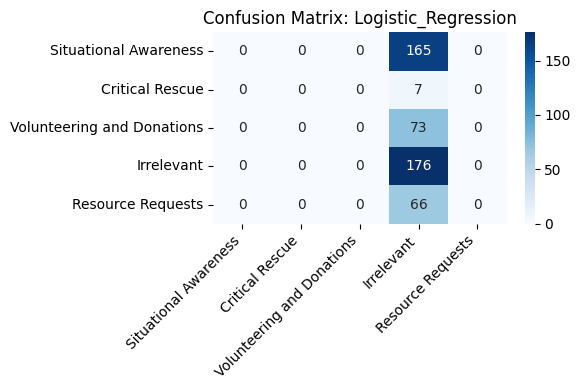

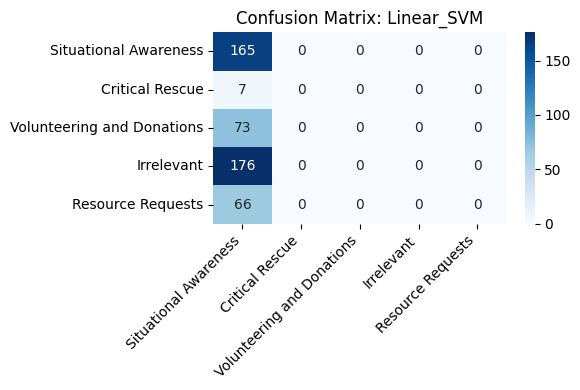

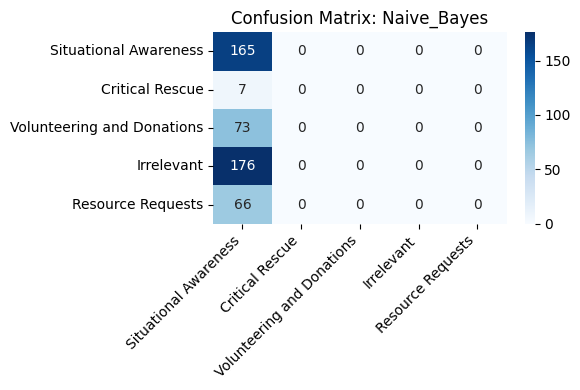

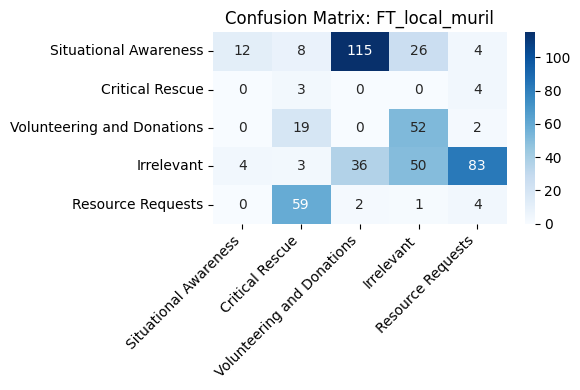

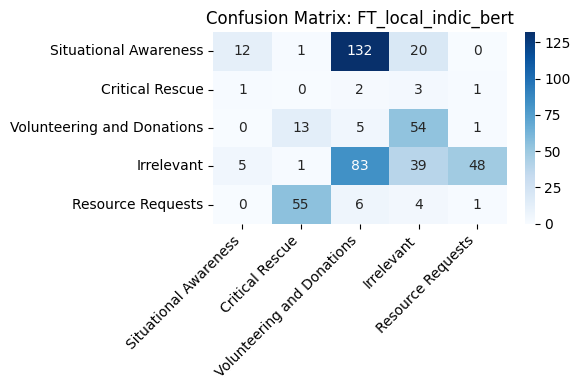

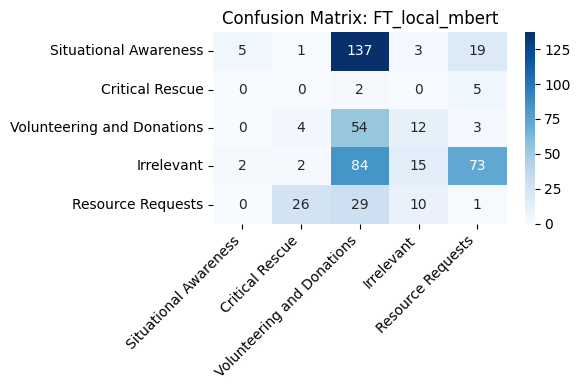

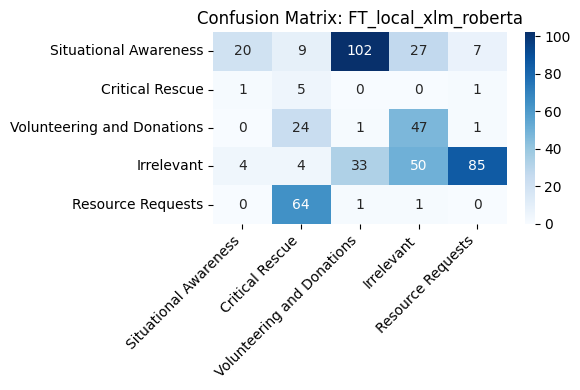

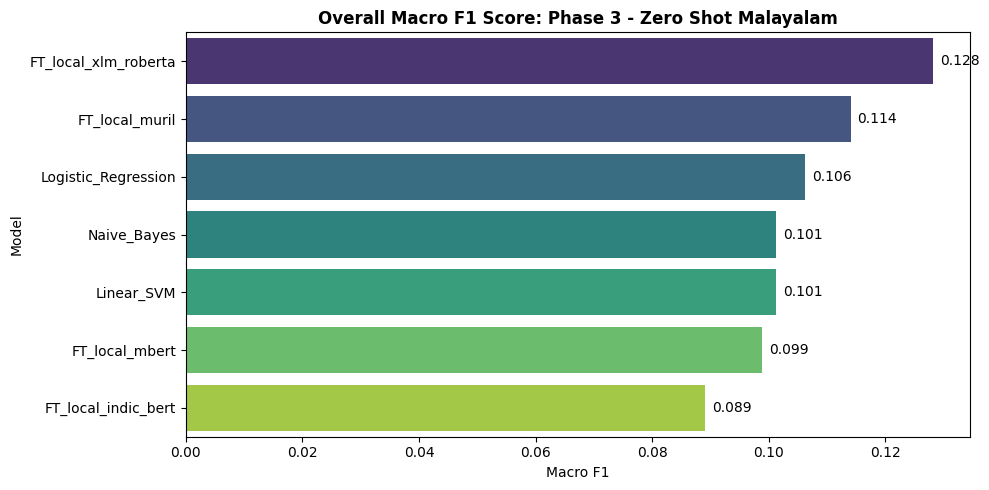

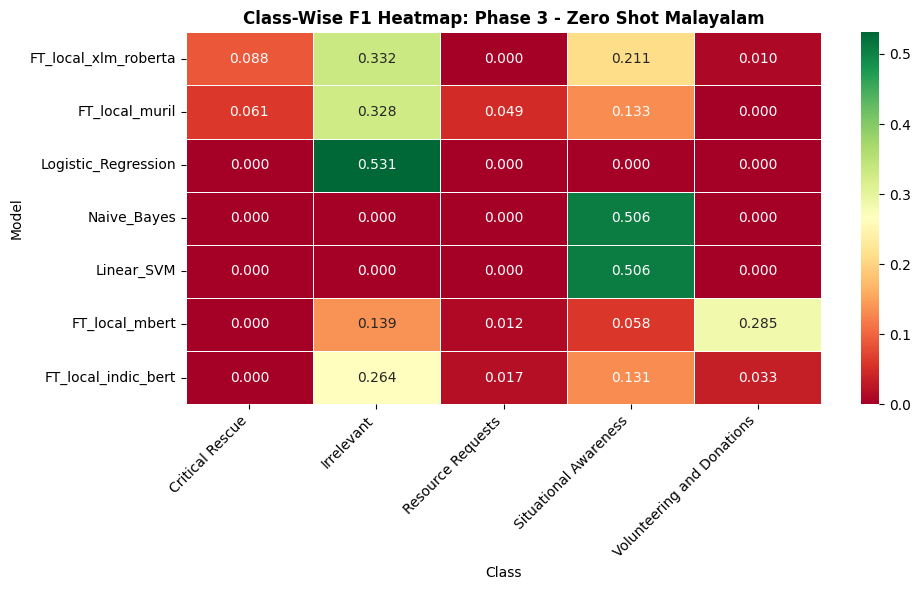

,Model,Accuracy,Precision,Recall,Macro F1
6,FT_local_xlm_roberta,0.156057,0.250894,0.226657,0.128154
3,FT_local_muril,0.141684,0.242289,0.169199,0.114030
0,Logistic_Regression,0.361396,0.072279,0.200000,0.106184
2,Naive_Bayes,0.338809,0.067762,0.200000,0.101227
1,Linear_SVM,0.338809,0.067762,0.200000,0.101227
5,FT_local_mbert,0.154004,0.255131,0.174082,0.098793
4,FT_local_indic_bert,0.117043,0.206641,0.075593,0.088996


,Model,Accuracy,Precision,Recall,Macro F1
6,FT_local_xlm_roberta,0.156057,0.250894,0.226657,0.128154
3,FT_local_muril,0.141684,0.242289,0.169199,0.114030
0,Logistic_Regression,0.361396,0.072279,0.200000,0.106184
2,Naive_Bayes,0.338809,0.067762,0.200000,0.101227
1,Linear_SVM,0.338809,0.067762,0.200000,0.101227
5,FT_local_mbert,0.154004,0.255131,0.174082,0.098793
4,FT_local_indic_bert,0.117043,0.206641,0.075593,0.088996


In [28]:
evaluate_and_plot(mal_true_labels, mal_preds, "Phase 3 - Zero Shot Malayalam")

In [29]:
print("Transliterating Malayalam to Manglish...")
mal_df["manglish_text"] = mal_df["text"].apply(
    lambda x: sanscript.transliterate(str(x), sanscript.MALAYALAM, sanscript.ITRANS)
)

Transliterating Malayalam to Manglish...


In [30]:
manglish_preds = predict_ml_models(mal_df["manglish_text"])

for name in transformer_names:
    tuned_path = find_latest_finetuned_model(name)
    if tuned_path is None:
        print(f"No fine-tuned model found for {name}. Skipping.")
        continue

    print(f"Loading FT {name} for Manglish from {tuned_path}")
    preds = predict_transformer(tuned_path, mal_df["manglish_text"])
    if preds:
        manglish_preds[f"FT_{name}"] = preds

Loading FT local_muril for Manglish from /home/aakash/rizwan/NLP_Project/results/local_muril_20260425_130411_no_aug/final_model


The tokenizer you are loading from '/home/aakash/rizwan/NLP_Project/results/local_muril_20260425_130411_no_aug/final_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Predicting final_model:   0%|          | 0/16 [00:00<?, ?it/s]

Loading FT local_indic_bert for Manglish from /home/aakash/rizwan/NLP_Project/results/local_indic_bert_20260425_131427_no_aug/final_model


Predicting final_model:   0%|          | 0/16 [00:00<?, ?it/s]

...

Loading FT local_mbert for Manglish from /home/aakash/rizwan/NLP_Project/results/local_mbert_20260425_130933_no_aug/final_model


Predicting final_model:   0%|          | 0/16 [00:00<?, ?it/s]

Loading FT local_xlm_roberta for Manglish from /home/aakash/rizwan/NLP_Project/results/local_xlm_roberta_20260425_131817_no_aug/final_model


The tokenizer you are loading from '/home/aakash/rizwan/NLP_Project/results/local_xlm_roberta_20260425_131817_no_aug/final_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Predicting final_model:   0%|          | 0/16 [00:00<?, ?it/s]


========== Generating Results for Phase 4 - Zero Shot Manglish ==========


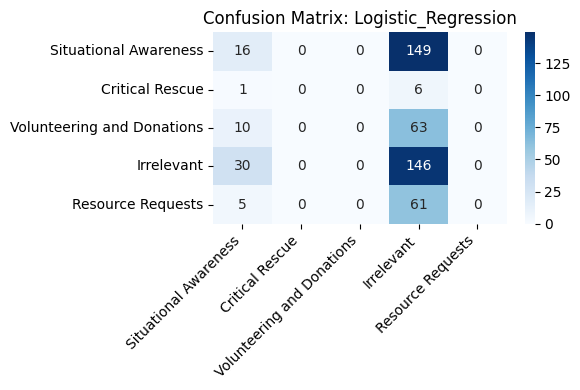

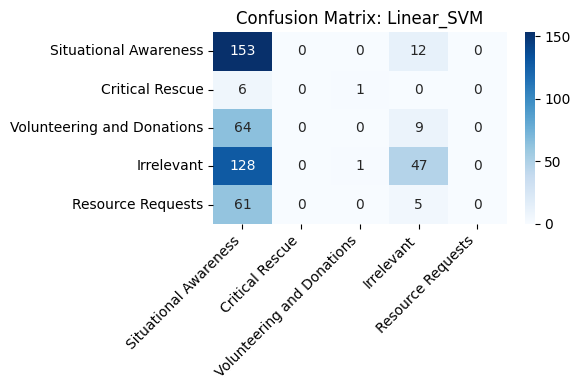

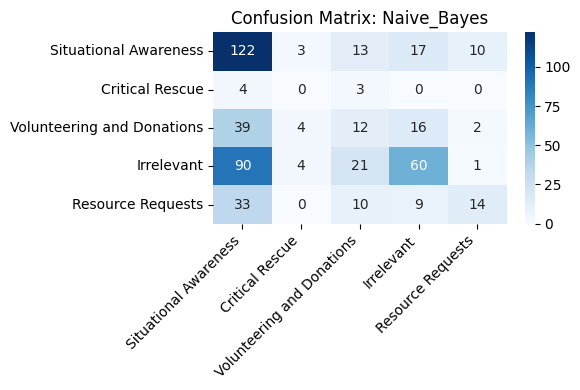

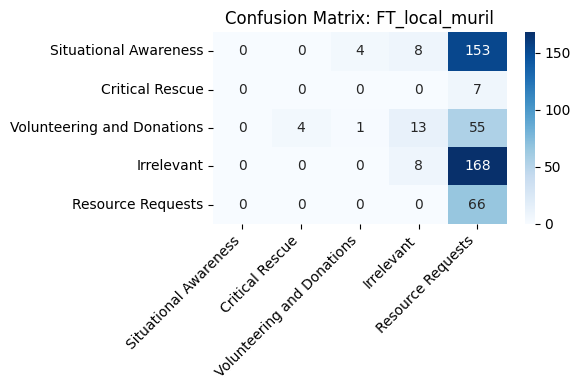

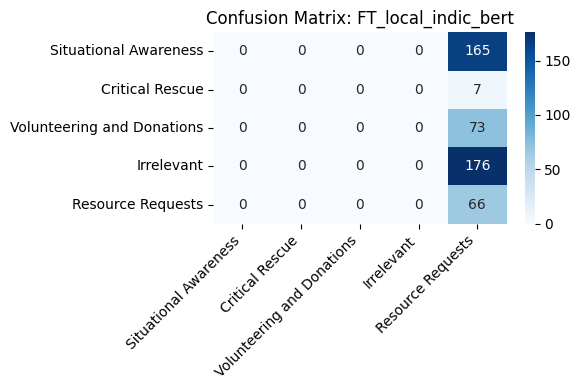

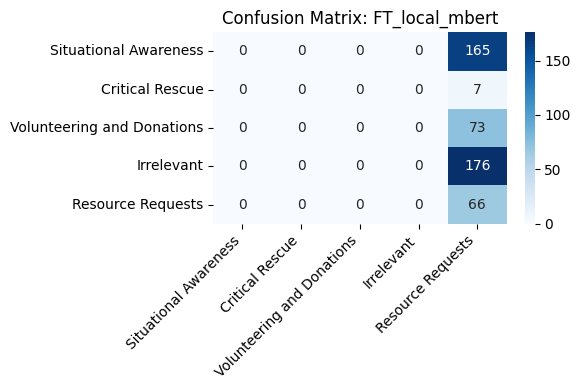

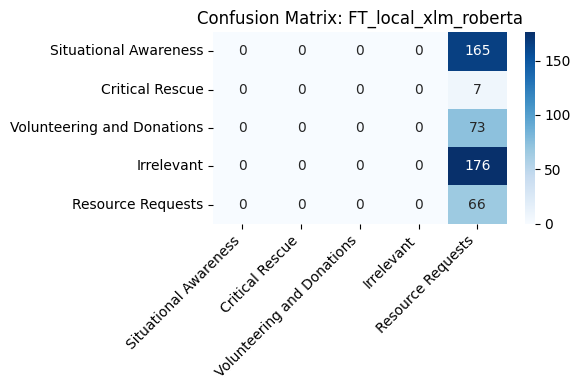

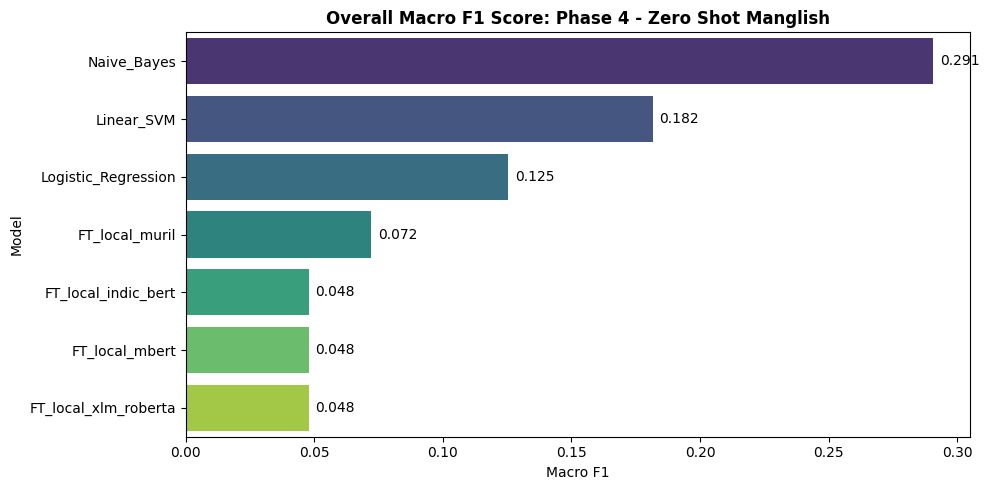

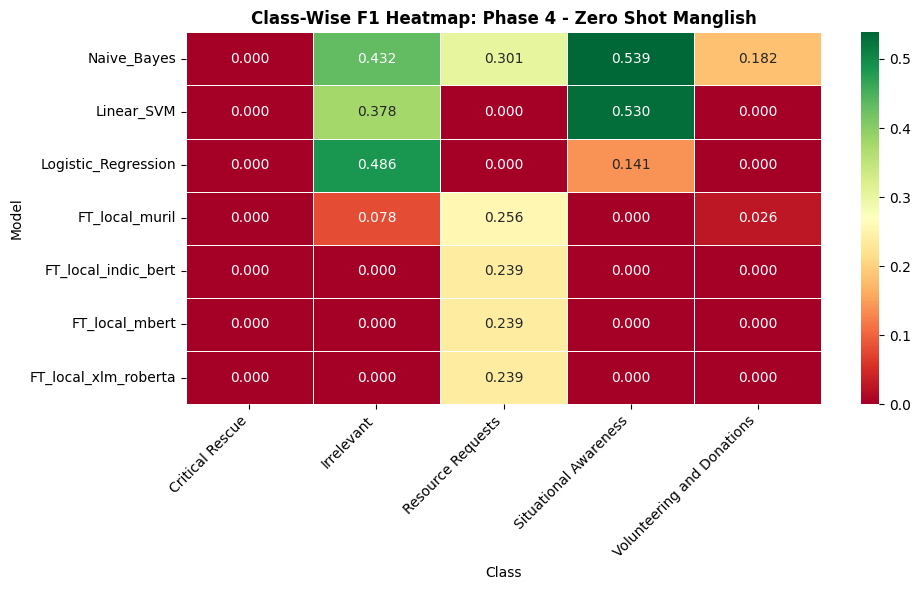

,Model,Accuracy,Precision,Recall,Macro F1
2,Naive_Bayes,0.427105,0.346751,0.291362,0.290636
1,Linear_SVM,0.410678,0.203039,0.238864,0.181568
0,Logistic_Regression,0.332649,0.120319,0.185303,0.125365
3,FT_local_muril,0.154004,0.124571,0.211831,0.072000
4,FT_local_indic_bert,0.135524,0.027105,0.200000,0.047740
5,FT_local_mbert,0.135524,0.027105,0.200000,0.047740
6,FT_local_xlm_roberta,0.135524,0.027105,0.200000,0.047740


,Model,Accuracy,Precision,Recall,Macro F1
2,Naive_Bayes,0.427105,0.346751,0.291362,0.290636
1,Linear_SVM,0.410678,0.203039,0.238864,0.181568
0,Logistic_Regression,0.332649,0.120319,0.185303,0.125365
3,FT_local_muril,0.154004,0.124571,0.211831,0.072000
4,FT_local_indic_bert,0.135524,0.027105,0.200000,0.047740
5,FT_local_mbert,0.135524,0.027105,0.200000,0.047740
6,FT_local_xlm_roberta,0.135524,0.027105,0.200000,0.047740


In [31]:
evaluate_and_plot(mal_true_labels, manglish_preds, "Phase 4 - Zero Shot Manglish")